In [1]:
import operator
import string
import jieba
import pandas as pd
import re
from ast import literal_eval
import jieba.posseg as psg
import jieba.posseg as pseg   # 分词处理
from pyltp import SentenceSplitter
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer # 计算tfidf值
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)#加了这一行那表格的一行就不会分段出现了
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows', None)



In [3]:

bjh_DF = pd.read_csv("../Data/merged_file_bjh.csv", encoding="utf-8")
bz_DF = pd.read_csv("../Data/merged_file_bz.csv", encoding="utf-8")
wb_DF = pd.read_csv("../Data/merged_file_wb.csv", encoding="utf-8")
zh_DF = pd.read_csv("../Data/merged_file_zh.csv", encoding="utf-8")

In [5]:

# 用于保存评论分词后的文本
Sentences_token_list = []

# 将分词结果列表转换为字符串，并将其添加到全局变量Sentences_token_list中
def get_sentences_token_list(TokenList):
    TokenList = literal_eval(TokenList)
    TokenStr = ' '.join(TokenList)
    Sentences_token_list.append(TokenStr)

# 使用肘部法确定最优聚类类数
def k_means_k(array):
    cost=[]
    for i in range (2,50):
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(array)
        cost.append(kmeans.inertia_)
    plt.plot(range(2,50), cost)
    plt.title("The Elbow Method")
    plt.xlabel("Num of clusters")
    plt.ylabel("Cost")
    plt.show()

# 对评论文本进行聚类，并返回聚类结果
def GetCluster(DF, DF_name):
    global Sentences_token_list  # 声明 Sentences_token_list 为全局变量
    Sentences_token_list = []  # 初始化 Sentences_token_list
    temp1 = DF["文本分词"].apply(get_sentences_token_list)  # 生成 Sentences_token_list
    tfidf_vec = TfidfVectorizer()
    tfidf_matrix = tfidf_vec.fit_transform(Sentences_token_list)
    array = tfidf_matrix.toarray()
    feature_words = tfidf_vec.get_feature_names()
    k_means_k(tfidf_matrix)  # 确定最优类数
    num_clusters = 10

c:\Users\Universal\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


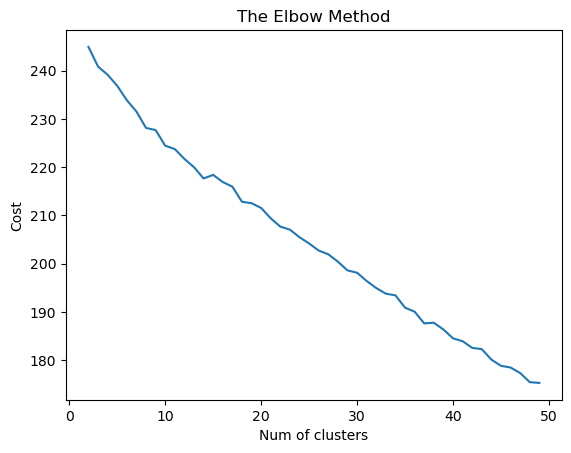

In [15]:
#分别返回并绘制每个平台数据的聚类结果
GetCluster(bjh_DF, DF_name="bjh")


c:\Users\Universal\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


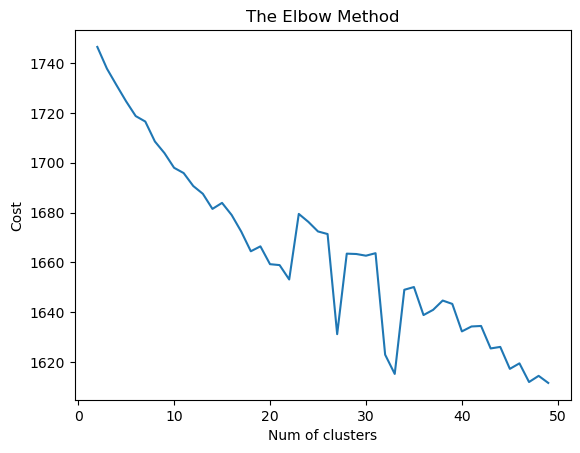

In [16]:
GetCluster(zh_DF, DF_name="zh")

c:\Users\Universal\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


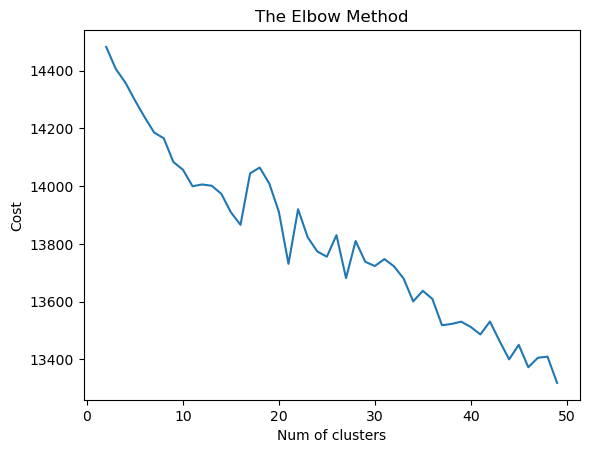

In [17]:
GetCluster(bz_DF, DF_name="bz")

c:\Users\Universal\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


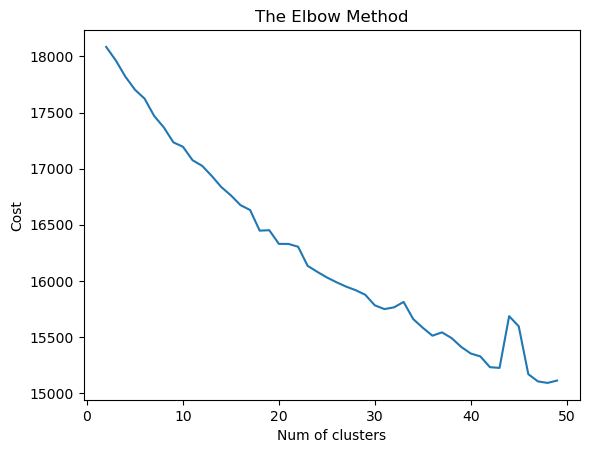

In [6]:
GetCluster(wb_DF, DF_name="wb")